[uptake] solver: The solver successfully reached the end of the integration interval.
sol.y shape: (303, 755)
pi: {'D': 18.100800000000003, 'K_on': 3067.4556213017754, 'K_off': 345.6, 'K_int': 1.2096, 'P': 388.8}


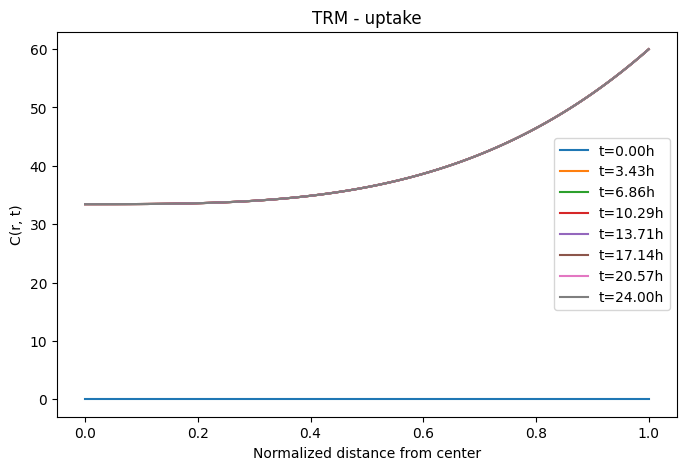

[clearance] solver: The solver successfully reached the end of the integration interval.
sol.y shape: (303, 442)
pi: {'D': 18.100800000000003, 'K_on': 3067.4556213017754, 'K_off': 345.6, 'K_int': 1.2096, 'P': 404352.0}


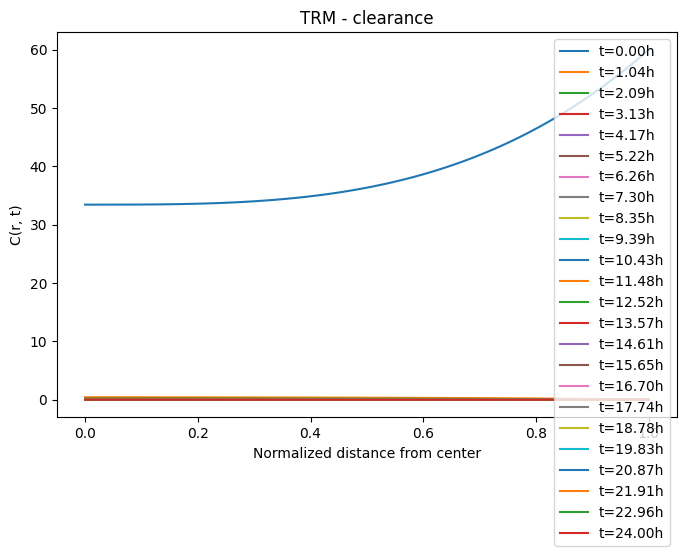

In [1]:
from pinnpy import fdm
import numpy as np

m = 100                         # number of steps.
y0_up = np.zeros(3 * (m+1))     # initial condition for uptake phase.
x_up, sol_up, final_up = fdm.run_phase(m=m, phase_name='uptake', y0=y0_up, time_splits=8, t_final=1.0)
x_cl, sol_cl, final_cl = fdm.run_phase(m=m, phase_name='clearance', y0=final_up, time_splits=24, t_final=1.0)

In [2]:
sol_up.y[:101, 0:50].shape

(101, 50)

In [3]:
sol_up.t < 1 /24

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

(101,)
(101,)
(101,)
(101,)
(101,)
(101,)
(101,)
(101,)


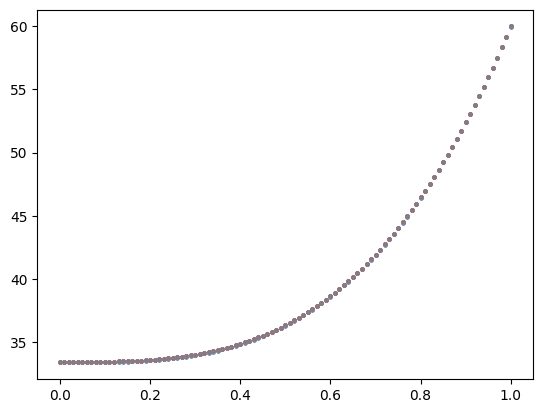

In [4]:
from pinnpy.fdm import plot_solution_at_phase
import matplotlib.pyplot as plt
for t in [1, 4, 6, 9, 12, 16, 20, 24]:
    y1 = sol_up.sol(t/24)[:101]
    print(y1.shape)
    plt.scatter(x_up, y1, s=5)

[uptake] solver: The solver successfully reached the end of the integration interval.
sol.y shape: (303, 237)
pi: {'D': 18.100800000000003, 'K_on': 51.124260355029584, 'K_off': 345.6, 'K_int': 1.2096, 'P': 0.108}


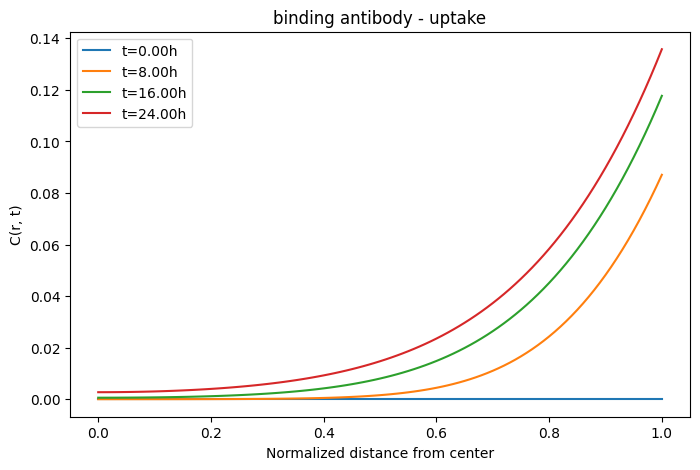

In [5]:
"""Finite-difference reference solver (the "oracle") for the Trastuzumab
uptake/clearance model.

Method of lines: discretize the radial operator into a matrix, then hand the
resulting stiff ODE system to scipy's BDF integrator. Physics is imported
from spheroid_deepxde.constants, so this solver and the PINN consume identical
parameters by construction.

Scope: uptake (primary), clearance (dormant scaffolding). Fishing removed.
"""

import numpy as np
from scipy.integrate import solve_ivp

"""Single source of truth for Trastuzumab transport/reaction physics.

Both the PINN model and the FDM reference oracle import from here, so they
cannot disagree on physical parameters by construction (Single-Source-of-
Truth: there is only one copy of each number, so there is nothing to drift).

Conventions:
    - concentrations in nM, length in um, time in sec (internally)
    - normalized spatial domain r in [0, 1]; tau folded into the nondim groups
    - physical-nM nondimensionalization (concentrations kept in nM; only time
      and space normalized) -- this is the corrected convention.

Scope: uptake (primary) + clearance (dormant). Fishing is out of scope.
"""

# --- raw physical constants (paper-fitted, Trastuzumab) ---------------------
R = 200.0           # spheroid radius (um)
C_STAR = 1.0        # characteristic concentration (nM)

D_EFF = 8.38        # antibody diffusion coeff in interstitium (um^2/sec)
K_OFF = 4e-3        # dissociation rate constant (1/sec)
K_D = 6.76          # equilibrium dissociation constant, K_D = k_off/k_on (nM)
K_INT = 1.4e-5      # internalization rate constant (1/sec)
R_T = 1060.0        # total receptor concentration (nM)
K_ON = K_OFF / K_D  # association rate constant (1/(sec*nM))

# --- per-phase scales -------------------------------------------------------
TAU = {             # characteristic time of each phase (sec)
    'uptake': 24 * 3600,
    'clearance': 24 * 3600,
}
C_SOL = {           # bath antibody concentration (nM)
    'uptake': 60.0,
    'clearance': 0.0,
}
P = {               # surface mass-transfer coefficient (um/sec)
    'uptake': 2.5e-4,
    'clearance': 2.6e-1,
}


def phi(r):
    """Porosity profile phi(r) = 0.44 r^3.2 + 0.56.

    Works on numpy arrays (FDM) and torch tensors (PINN): both overload **
    and *, so one definition serves both backends.
    """
    return 0.44 * r ** 3.2 + 0.56


def dphi_dr(r):
    """Analytic derivative phi'(r) = 0.44 * 3.2 * r^2.2.

    Co-located with phi() so the value and its derivative cannot drift apart.
    The PINN takes derivatives via autograd and does not need this; the FDM
    operator does.
    """
    return 0.44 * 3.2 * r ** 2.2


def nondim_params(phase):
    """Dimensionless PDE coefficients on the normalized [0, 1] domain.

    Returns exactly the keys both the FDM and the PINN consume:
        D, K_on, K_off, K_int, P

    Phase-dependent because each group carries tau[phase].
    """
    t = TAU[phase]
    return {
        'D':     t / R ** 2 * D_EFF,
        'K_on':  t * C_STAR * K_ON,
        'K_off': t * K_OFF,
        'K_int': t * K_INT,
        'P':     t / R * P[phase],
    }

def get_mat(diag_size, sub, main, sup):
    """Tridiagonal matrix with constant sub / main / super diagonals."""
    return (
        sub * np.diag(np.ones(diag_size - 1), k=-1)
        + main * np.diag(np.ones(diag_size), k=0)
        + sup * np.diag(np.ones(diag_size - 1), k=1)
    )


def compute_diff_matrices(m, a, b):
    """Central-difference operators on [a, b] with m steps (size m+1).

    Returns x, h, Dx/(2h), Dxx/h^2.
    """
    h = (b - a) / m
    x = a + h * np.arange(m + 1)
    Dx = get_mat(m + 1, sub=-1, main=0, sup=1)
    Dxx = get_mat(m + 1, sub=1, main=-2, sup=1)
    return x, h, Dx / (2 * h), Dxx / h ** 2


def get_diffusion_differential_operator(m, x_domain, phase, debug=False):
    """Build the discretized diffusion operator L_c acting on concentration c.

    L_u acts on u = c/phi; we fold phi^-1 in so L_c = L_u @ diag(1/phi).
    Boundary rows are overwritten to embed:
        r=0 : symmetry (Neumann), with l'Hopital factor 3 on the 2nd deriv.
        r=R : Robin flux.

    Returns x, L_c, b  where b carries the external-influx constant term.
    """
    pi = nondim_params(phase)
    D_eff = pi['D']
    P = pi['P']

    x, h, Dx, Dxx = compute_diff_matrices(m, x_domain[0], x_domain[1])

    x_inv = np.zeros_like(x)
    x_inv[1:] = 1.0 / x[1:]

    phi_arr = phi(x)            # porosity values
    phi_prime = dphi_dr(x)      # dphi/dr

    # r=0 symmetry: kill the advection row, apply l'Hopital (factor 3).
    Dx[0, :] = 0
    Dxx[0, 0] = 3 * -2 / h ** 2
    Dxx[0, 1] = 3 * 2 / h ** 2

    # r=R Robin BC.
    alpha = 2 * h * P / D_eff / phi_arr[m]
    Dx[m, m] = -alpha / (2 * h)
    Dx[m, m - 1] = 0
    Dxx[m, m] = -(2 + alpha) / h ** 2
    Dxx[m, m - 1] = 2 / h ** 2

    # operator on u = c/phi
    C2 = D_eff * phi_arr
    C1 = 2 * D_eff * phi_arr * x_inv + D_eff * phi_prime
    L_u = np.diag(C2) @ Dxx + np.diag(C1) @ Dx

    # influx constant term at the surface node
    b = np.zeros_like(x)
    b[m] = (C2[m] / h ** 2 + C1[m] / (2 * h)) * alpha * C_SOL[phase]

    # operator on concentration c
    L_c = L_u @ np.diag(1.0 / phi_arr)

    if debug:
        print(f'h={h}  alpha={alpha}')
        print(f'L_c shape {L_c.shape}')
    return x, L_c, b


def _rhs(t, y, N, L_c, b, pi, phi_arr):
    """Method-of-lines RHS for the three coupled species.

    Constants (pi, L_c, b, phi_arr) are passed in via args rather than
    recomputed each call -- the integrator evaluates this thousands of times.
    """
    cf = y[:N]
    cb = y[N:2 * N]
    ci = y[2 * N:]

    diffusion = L_c @ cf + b
    reaction = pi['K_on'] * cf / phi_arr * (R_T / C_STAR - cb) - pi['K_off'] * cb
    internalization = pi['K_int'] * cb   # acts on BOUND (corrected)

    cf_t = diffusion - reaction
    cb_t = reaction - internalization
    ci_t = internalization
    return np.concatenate([cf_t, cb_t, ci_t])


def run_fdm(m, phase_name, y0, t_final=1.0):
    N = m + 1
    x, L_c, b = get_diffusion_differential_operator(m, [0, 1], phase_name)
    pi = nondim_params(phase_name)
    phi_arr = phi(x)

    sol = solve_ivp(
        fun=_rhs,
        t_span=[0, t_final],
        y0=y0,
        method='BDF',
        args=(N, L_c, b, pi, phi_arr),
        dense_output=True,
        rtol=1e-6,
        atol=1e-9,
    )
    print(f'[{phase_name}] solver: {sol.message}')
    return x, sol


def plot_solution_at_phase(x, sol, time_splits, phase_name):
    import matplotlib.pyplot as plt
    N = len(x)
    t = np.linspace(0, 1.0, time_splits)
    tau_h = TAU[phase_name] / 3600  # label in hours

    plt.figure(figsize=(8, 5))
    plt.plot(x, sol.sol(t)[:N, :])   # free antibody cf
    plt.xlabel('Normalized distance from center')
    plt.ylabel('C(r, t)')
    plt.title(f'binding antibody - {phase_name}')
    plt.legend([f't={tj * tau_h:.2f}h' for tj in t])
    plt.show()


def run_phase(m, phase_name, y0, time_splits, t_final):
    x, sol = run_fdm(m, phase_name, y0, t_final)
    print('sol.y shape:', sol.y.shape)
    print('pi:', nondim_params(phase_name))
    plot_solution_at_phase(x, sol, time_splits, phase_name)
    return x, sol, sol.y[:, -1]


if __name__ == '__main__':
    m = 100
    N = m + 1
    y0_up = np.zeros(3 * N)
    x, sol_up, final_up = run_phase(m, 'uptake', y0_up, time_splits=4, t_final=1.0)
    # clearance is dormant; uncomment once P_cl units are resolved:
    # sol_cl, _ = run_phase(m, 'clearance', final_up, time_splits=4, t_final=1.0)

In [6]:
import torch
def relative_l2_error(y_pred, y_true):
    return torch.linalg.norm(y_pred - y_true) / torch.linalg.norm(y_true)

In [8]:
import numpy as np
import torch
from pinnpy import neural_nets
from pinnpy.preprocessing.normalization import ZScoreNormalizer

# --- take the grid
m = 101
X, T = np.meshgrid(x, sol_up.t, indexing='ij')
# --- raw
x_train = torch.tensor(np.column_stack([X.flatten(), T.flatten()]), dtype=torch.float32)
targets = torch.tensor(sol_up.y[:m].flatten()[:, np.newaxis], dtype=torch.float32)
# --- save mean, std
x_normalizer = ZScoreNormalizer().fit(x_train)
y_normalizer = ZScoreNormalizer().fit(targets)
# --- normalize
x_train_norm = x_normalizer.transform(x_train)
targets_norm = y_normalizer.transform(targets)
# --- prepare the network
inits = [None, 'xavier_uniform', 'xavier_normal']

models = []
for init_name in inits:
    model = neural_nets.FCNN(n_layers=3, n_neurons=64, initialization=init_name)
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    epochs = 10000
    # --- train
    print(f'training...')
    epoch = 0
    while epoch < epochs:
        model.train()
        u0_norm = model(x_train_norm)[:, 0:1]
        loss = criterion(u0_norm, targets_norm)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch += 1
        if (epoch + 1) % 1000 == 0:
            u0_raw = y_normalizer.inverse_transform(u0_norm)
            rl2 = relative_l2_error(u0_raw, targets) * 100
            print(f"Epoch [{epoch+1}] - Loss (MSE): {loss.item():.1e} - RL2: {rl2:.2f}%")
    models.append(model)


weight have not been initialized.
training...
Epoch [1000] - Loss (MSE): 9.3e-04 - RL2: 2.91%
Epoch [2000] - Loss (MSE): 4.6e-04 - RL2: 2.05%
Epoch [3000] - Loss (MSE): 4.4e-04 - RL2: 1.99%
Epoch [4000] - Loss (MSE): 2.8e-04 - RL2: 1.61%
Epoch [5000] - Loss (MSE): 2.5e-04 - RL2: 1.50%
Epoch [6000] - Loss (MSE): 2.3e-04 - RL2: 1.44%
Epoch [7000] - Loss (MSE): 2.1e-04 - RL2: 1.39%
Epoch [8000] - Loss (MSE): 2.0e-04 - RL2: 1.36%
Epoch [9000] - Loss (MSE): 2.0e-04 - RL2: 1.34%
Epoch [10000] - Loss (MSE): 1.9e-04 - RL2: 1.32%
neural network weights initialized succesfully - initializer: xavier_uniform
training...
Epoch [1000] - Loss (MSE): 2.8e-03 - RL2: 5.04%
Epoch [2000] - Loss (MSE): 1.0e-03 - RL2: 3.03%
Epoch [3000] - Loss (MSE): 6.1e-04 - RL2: 2.36%
Epoch [4000] - Loss (MSE): 4.6e-04 - RL2: 2.04%
Epoch [5000] - Loss (MSE): 3.8e-04 - RL2: 1.85%
Epoch [6000] - Loss (MSE): 3.2e-04 - RL2: 1.71%
Epoch [7000] - Loss (MSE): 2.9e-04 - RL2: 1.61%
Epoch [8000] - Loss (MSE): 2.6e-04 - RL2: 1.55%


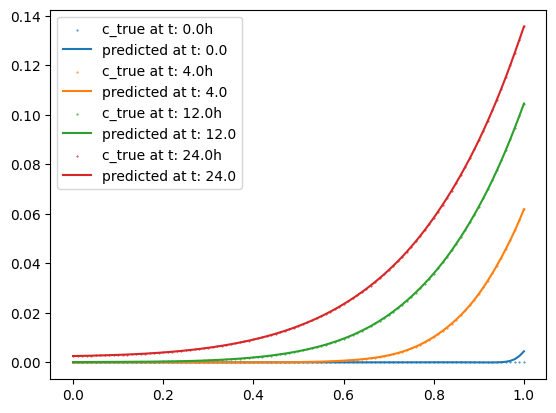

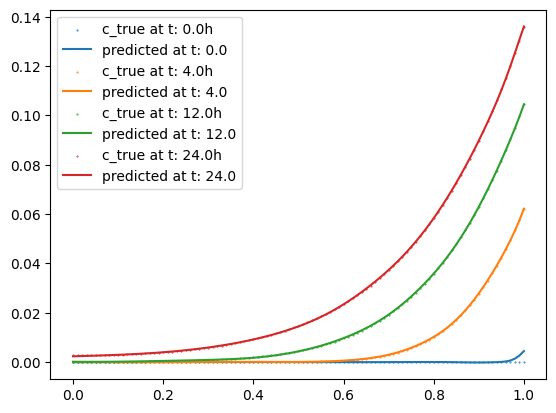

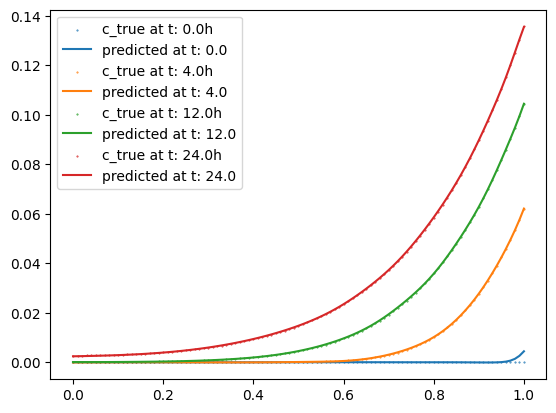

In [ ]:
import matplotlib.pyplot as plt

times = [0/24, 4/24, 12/24, 24/24]

for model in models:
    fig = plt.figure()
    for t in times: 
        data_tensor_raw = torch.tensor(np.column_stack([x, np.full_like(x, t)]), dtype=torch.float32)
        data_tensor_norm = x_normalizer.transform(data_tensor_raw)

        u0_norm = model(data_tensor_norm)[:, 0:1]
        u0_raw = y_normalizer.inverse_transform(u0_norm)

        plt.scatter(x, sol_up.sol(t)[:101], s=0.2, label=f'c_true at t: {t*24}h')
        plt.plot(x, u0_raw.detach(), label=f'predicted at t: {t*24}')
        
        plt.legend()

ValueError: x and y must be the same size

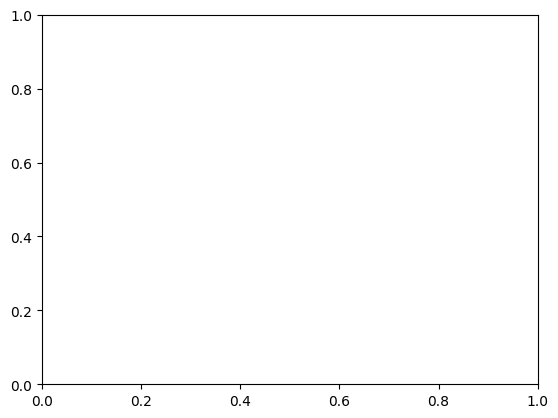

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def take_dataset_at_time(time: float, x: np.ndarray):
    r = x.reshape(-1, 1)
    u = sol_up.sol(time)[:101].reshape(-1, 1)
    data = np.hstack((r, time))
    return data, u

times = [1/24, 4/24, 8/24, 12/24, 18/24, 24/24]
u = sol_up.sol(0/24)[:101].reshape(-1, 1)
for t in times:
    u = np.hstack((u, sol_up.sol(t)[:101].reshape(-1, 1)))

u_true = u

plt.scatter(x, u_true[0, :])
# data1, u1 = take_dataset_at_time(1/24, x)
# data4, u4 = take_dataset_at_time(4/24, x)
# data8, u8 = take_dataset_at_time(8/24, x)
# data12, u12 = take_dataset_at_time(12/24, x)
# data18, u18 = take_dataset_at_time(18/24, x)
# data24, u24 = take_dataset_at_time(24/24, x)

# datasets = (data1, data4, data8, data12, data18, data24)
# data = np.hstack(datasets)


neural network weights initialized succesfully


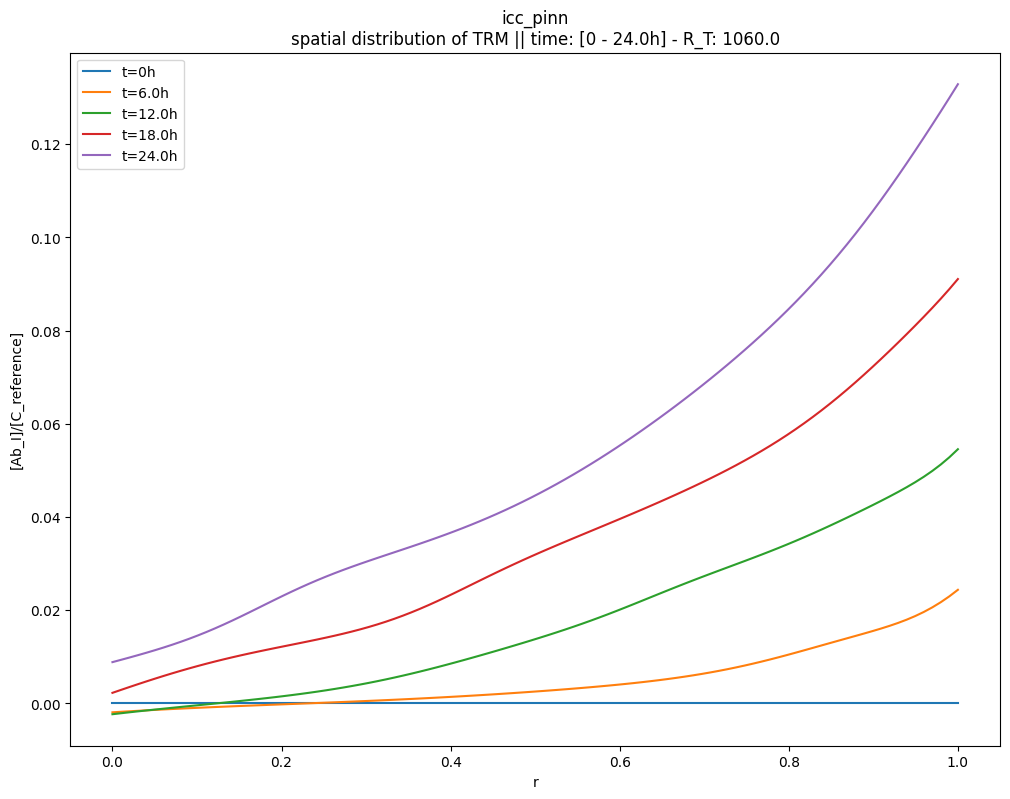

In [ ]:
from pathlib import Path
import torch
from pinnpy import neural_nets
from pinnpy.utils import plotting as pl

model_name = 'icc_pinn'
p = Path.cwd().parent/f'models/{model_name}.pt'

fcnn = neural_nets.FCNN(3, 64)
state_dict = torch.load(p)['state_dict']
fcnn.load_state_dict(state_dict)

pl.get_spatial_antibody_distribution(1.0, model_name, fcnn, 1.0)

# from pinnpy import fdm, evaluation
# import numpy as np

# fdm_x, fdm_sol = fdm.run_fdm(m=100, phase_name='uptake', y0=np.zeros(3*(100+1)), t_final=1.0)
# ev = evaluation.Evaluator(fdm_x, fdm_sol.sol, n_t=101)


